## Image Classification Submission


> Dataset diperoleh dari [kaggle](https://www.kaggle.com/datasets/vencerlanz09/bottle-synthetic-images-dataset)

> Dataset berisi 5 kelas data klasifikasi botol


> Jumlah dataset 25000 gambar dengan resolusi yang berbeda-beda

### Import Library

In [8]:
import importlib.util
import subprocess
import sys

required_packages = [
    "kagglehub",
    "tensorflow",
    "tensorflowjs",
    "split-folders",
    "numpy",
    "opencv-python",
    "pandas",
    "matplotlib",
    "seaborn",
]

missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg.split("-")[0]) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import kagglehub
import os
import splitfolders
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


### Prepare Data from Kaggle API

In [9]:
try:
    path = kagglehub.dataset_download("vencerlanz09/bottle-synthetic-images-dataset")
    print("Path to dataset files:", path)
except Exception as err:
    raise RuntimeError(
        "Download gagal. Pastikan koneksi internet aktif, lalu jalankan ulang cell ini."
    ) from err

Using Colab cache for faster access to the 'bottle-synthetic-images-dataset' dataset.
Path to dataset files: /kaggle/input/bottle-synthetic-images-dataset


In [10]:
data = os.path.join(path, "Bottle Images", "Bottle Images")

WORK_DIR = os.path.join(os.getcwd(), "working_dataset")
SPLIT_DIR = os.path.join(WORK_DIR, "split")
TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

os.makedirs(WORK_DIR, exist_ok=True)

if not (os.path.exists(TRAIN_DIR) and os.path.exists(VAL_DIR) and os.path.exists(TEST_DIR)):
    splitfolders.ratio(
        data,
        output=SPLIT_DIR,
        seed=42,
        ratio=(0.8, 0.1, 0.1),
        group_prefix=None
    )

print("Dataset split directory:", SPLIT_DIR)


### Kelas data pada Dataset

In [11]:
source_class_names = sorted(os.listdir(data))
source_class_names


['Water Bottle',
 'Plastic Bottles',
 'Beer Bottles',
 'Soda Bottle',
 'Wine Bottle']

### Sample Image Data dengan Resolusi yang berbeda-beda

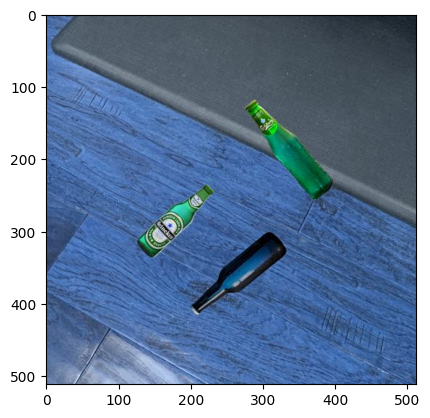

In [12]:
img = cv2.imread(os.path.join(data, 'Beer Bottles', '00000000.jpg'))
plt.imshow(img)
plt.show()

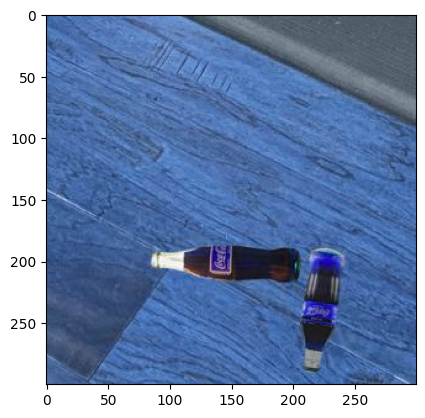

In [13]:
img = cv2.imread(os.path.join(data, 'Soda Bottle', '00000000.jpg'))
plt.imshow(img)
plt.show()

### Augmentasi Data

In [14]:
train_generator = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
    horizontal_flip=True,
    rescale=1./255
)

eval_generator = ImageDataGenerator(
    rescale=1./255
)


In [15]:
data_train = train_generator.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)


Found 20000 images belonging to 5 classes.


In [16]:
data_val = eval_generator.flow_from_directory(
    VAL_DIR,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

data_test = eval_generator.flow_from_directory(
    TEST_DIR,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

class_names = sorted(data_train.class_indices, key=data_train.class_indices.get)
assert class_names == sorted(data_val.class_indices, key=data_val.class_indices.get)
assert class_names == sorted(data_test.class_indices, key=data_test.class_indices.get)
class_names


Found 5000 images belonging to 5 classes.


### Define Learning Rate

In [17]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


### Arsitektur Model

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax'),
])
model.compile(loss = "categorical_crossentropy", optimizer = optimizer , metrics = ["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Define Callbacks

In [19]:
# Callback agar model berhenti saat val_accuracy melampaui 97%
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > 0.97:
            print("\nVal accuracy telah melampaui 97%, membatalkan proses training")
            self.model.stop_training = True

callbacks = MyCallback()

### Define Early Stop Training per 10 epochs

In [20]:
checkpoint = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [21]:
# Re-compile model dengan optimizer yang stabil untuk Keras versi terbaru
optimizer = Adam(learning_rate=0.001)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"] )

history = model.fit(
    data_train,
    steps_per_epoch=max(1, data_train.samples // data_train.batch_size),
    epochs=32,
    validation_data=data_val,
    validation_steps=max(1, data_val.samples // data_val.batch_size),
    callbacks=[checkpoint, callbacks]
 )


Epoch 1/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 271s 422ms/step - accuracy: 0.4886 - loss: 1.1549 - val_accuracy: 0.6528 - val_loss: 0.9025
Epoch 2/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.7914 - loss: 0.5517 - val_accuracy: 0.8592 - val_loss: 0.4086
Epoch 3/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.8753 - loss: 0.3360 - val_accuracy: 0.7839 - val_loss: 0.6552
Epoch 4/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9132 - loss: 0.2404 - val_accuracy: 0.8848 - val_loss: 0.3760
Epoch 5/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.9328 - loss: 0.1900 - val_accuracy: 0.9311 - val_loss: 0.2121
Epoch 6/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 236ms/step - accuracy: 0.9455 - loss: 0.1569 - val_accuracy: 0.9553 - val_loss: 0.1320
Epoch 7/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.9518 - loss: 0.1400 - val_accuracy: 0.8590 - val_loss: 0.6035
Epoch 8/32
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9611 -

### Model Summary

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,235,569 (31.42 MB)

 Trainable params: 2,745,189 (10.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,490,380 (20.94 MB)

### Plot Loss dan Akurasi

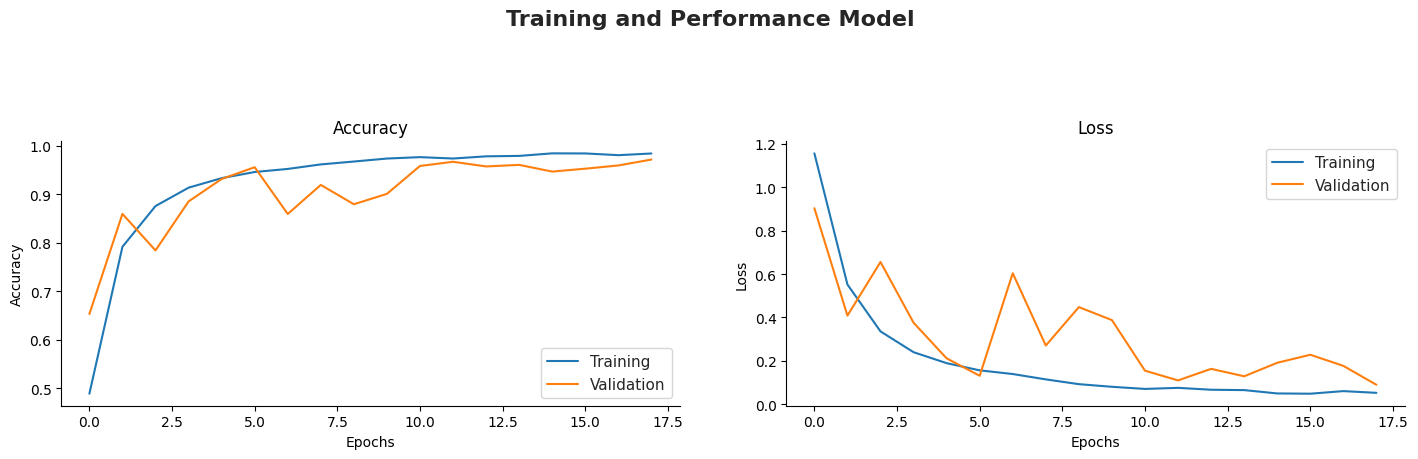

In [23]:
fig, axarr = plt.subplots(1,2, figsize=(15,5), sharex=True)

sns.set(style="ticks", font_scale = 1)
sns.despine(top=True, right=True, left=False, bottom=False)

historyDF = pd.DataFrame.from_dict(history.history)
ax = sns.lineplot(x = historyDF.index, y = history.history['accuracy'], ax=axarr[0], label="Training");
ax = sns.lineplot(x = historyDF.index, y = history.history['val_accuracy'], ax=axarr[0], label="Validation");
ax.set_ylabel('Accuracy')

ax = sns.lineplot(x = historyDF.index, y = history.history['loss'], ax=axarr[1], label="Training");
ax = sns.lineplot(x = historyDF.index, y = history.history['val_loss'], ax=axarr[1], label="Validation");
ax.set_ylabel('Loss')


axarr[0].set_title('Accuracy')
axarr[1].set_title('Loss')

for ax in axarr:
    ax.set_xlabel('Epochs')

plt.suptitle('Training and Performance Model', fontsize=16, weight='bold');
fig.tight_layout(pad=3.0)
plt.show()

### Save Model

In [25]:
# Simpan semua artefak model sesuai struktur folder submission
BASE_DIR = os.getcwd()
SAVED_MODEL_DIR = os.path.join(BASE_DIR, "saved_model")
TFLITE_DIR = os.path.join(BASE_DIR, "tflite")
TFJS_DIR = os.path.join(BASE_DIR, "tfjs_model")

os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
os.makedirs(TFLITE_DIR, exist_ok=True)
os.makedirs(TFJS_DIR, exist_ok=True)

# ✅ Keras 3: export SavedModel
model.export(SAVED_MODEL_DIR)
print("SavedModel tersimpan di:", SAVED_MODEL_DIR)

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  131977221995984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977221995408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977221994832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069822608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069822800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069823184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069824144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069822416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069823376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131977069824336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319772219

### Convert Model to TFLite

In [27]:
# Convert ke TFLite dan simpan label
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
tflite_model = converter.convert()

TFLITE_MODEL_PATH = os.path.join(TFLITE_DIR, "model.tflite")
with tf.io.gfile.GFile(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

LABEL_PATH = os.path.join(TFLITE_DIR, "label.txt")
with open(LABEL_PATH, "w", encoding="utf-8") as f:
    for label in class_names:
        f.write(f"{label}\n")

print("TFLite model tersimpan di:", TFLITE_MODEL_PATH)
print("Label tersimpan di:", LABEL_PATH)

# Convert ke TFJS bila package tensorflowjs tersedia
try:
    if importlib.util.find_spec("tensorflowjs") is None:
        print("tensorflowjs belum terpasang. Lewati export TFJS.")
    else:
        subprocess.check_call([
            sys.executable,
            "-m",
            "tensorflowjs.converters.converter",
            "--input_format=tf_saved_model",
            "--output_format=tfjs_graph_model",
            SAVED_MODEL_DIR,
            TFJS_DIR,
        ])
        print("TFJS model tersimpan di:", TFJS_DIR)
except Exception as err:
    print("Export TFJS gagal:", err)

TFLite model tersimpan di: /content/tflite/model.tflite
Label tersimpan di: /content/tflite/label.txt
TFJS model tersimpan di: /content/tfjs_model


### Inference Menggunakan Model TFLite

In [28]:
# Inference contoh dengan model TFLite
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_image_path = data_test.filepaths[0]
sample_img = cv2.imread(sample_image_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (150, 150))
sample_input = (sample_img.astype(np.float32) / 255.0)
sample_input = np.expand_dims(sample_input, axis=0)

interpreter.set_tensor(input_details[0]["index"], sample_input)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]["index"])[0]

pred_idx = int(np.argmax(pred))
pred_label = class_names[pred_idx]

print("Contoh gambar:", sample_image_path)
print("Prediksi kelas:", pred_label)
print("Skor probabilitas:", float(pred[pred_idx]))


Contoh gambar: /kaggle/input/bottle-synthetic-images-dataset/Bottle Images/Bottle Images/Water Bottle/00002170.jpg
Prediksi kelas: Soda Bottle
Skor probabilitas: 1.0


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
